<div style="background:linear-gradient(135deg,#0f172a 0%,#1e3a8a 50%,#312e81 100%);padding:40px;border-radius:14px;color:white;text-align:center;font-family:'Segoe UI',sans-serif;">

<h1 style="margin:0;font-size:42px;letter-spacing:1px;">Feature Detection</h1>
<h3 style="margin:8px 0 18px 0;font-weight:300;opacity:0.9;">Notebook 04 - Harris, SIFT, ORB & Matching</h3>

<p style="font-size:15px;opacity:0.85;margin:0;">Computer Vision Series - for AI Students & AI Engineers</p>
<p style="font-size:13px;opacity:0.7;margin-top:6px;">Prereqs: Notebooks 01-03</p>

</div>

---

> **Note:** All content in this notebook (text, structure, code) is for educational purposes. Always verify critical facts and run code in your own environment.

---

### Where we are in the series

| # | Notebook | Status |
|---|---|---|
| 01 | Foundations, History & Modern Toolkit | Done |
| 02 | Image Fundamentals & NumPy/OpenCV Core | Done |
| 03 | Image Processing & Filtering | Done |
| **04** | **Feature Detection (SIFT, ORB, Harris)** | *You are here* |
| 05 | Classical ML for Vision | upcoming |
| 06+ | Deep Learning, Detection, Segmentation, Generative, VLMs | upcoming |

---

### What you'll master in this notebook

1. **What features are** - and why "good" keypoints survive scale, rotation, lighting
2. **Harris corner detector** - the geometric foundation (1988, still essential)
3. **Shi-Tomasi (Good Features To Track)** - Harris's improved cousin
4. **SIFT** - scale-invariant features that powered a decade of CV
5. **ORB** - fast, free, modern alternative used in real-time systems
6. **Feature matching** - brute-force, FLANN, ratio test, RANSAC
7. **Capstone** - stitch two photos into a panorama using everything above

> Every section is runnable and uses synthetic images so the notebook works offline.


## 1. What Are Features and Why Do We Need Them?

A **feature** (or **keypoint**) is a small, distinctive image location that you can reliably re-detect when the image changes - different angle, lighting, scale, or partial occlusion.

### Why we need them

You cannot match images pixel-by-pixel - one rotation and every pixel is in the wrong place. Features give you a few hundred *anchor points* you can match across images. They are the basis for:

- Panorama stitching
- Object recognition (pre deep-learning)
- 3D reconstruction (Structure-from-Motion)
- Visual SLAM (robots, AR)
- Image alignment / registration
- Tracking objects across video frames

### What makes a "good" feature?

| Property | Meaning |
|---|---|
| **Repeatable** | Same physical point detected across views |
| **Distinctive** | Its descriptor is unique - few false matches |
| **Local** | Robust to occlusion / clutter |
| **Many** | Hundreds per image so a few good matches survive |
| **Efficient** | Cheap enough for real-time use |

### The three regions of an image

| Region | Detection difficulty |
|---|---|
| **Flat area** (constant intensity) | Bad - looks the same everywhere |
| **Edge** | Mediocre - position uncertain along the edge |
| **Corner** | Great - position locked in both directions |

**Corners are the canonical feature.** Most classical detectors hunt for them.


## 2. Harris Corner Detector (1988)

Harris detects corners by looking at how the intensity changes when you shift a small window in any direction.

### The intuition

- Slide a window over a flat region: intensity barely changes -> not a corner
- Slide it along an edge: changes only in one direction -> still not a corner
- Slide it on a corner: changes in **both** directions -> corner

### The math (clean version)

For each pixel, build the structure tensor `M` from image gradients in a small window:

$$
M = \sum_w
\begin{bmatrix}
I_x^2 & I_x I_y \\
I_x I_y & I_y^2
\end{bmatrix}
$$

Then compute the **Harris response**:

$$R = \det(M) - k \cdot \text{trace}(M)^2$$

where `k` is usually 0.04-0.06.

| Eigenvalues of M | Region | Harris response R |
|---|---|---|
| Both small | Flat | small |
| One large, one small | Edge | negative |
| Both large | Corner | large positive |


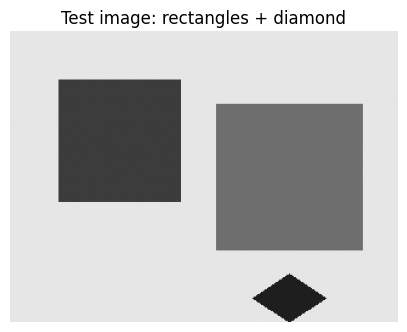

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Build a test image with clear corners, edges, and flat areas
H, W = 240, 320
img = np.full((H, W), 230, dtype=np.uint8)
cv2.rectangle(img, (40, 40), (140, 140), 60, -1)
cv2.rectangle(img, (170, 60), (290, 180), 110, -1)

# Add a rotated diamond for variety
pts = np.array([[230, 200], [260, 220], [230, 240], [200, 220]], dtype=np.int32)
cv2.fillPoly(img, [pts], 30)

plt.figure(figsize=(5, 4))
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Test image: rectangles + diamond")
plt.axis("off")
plt.show()

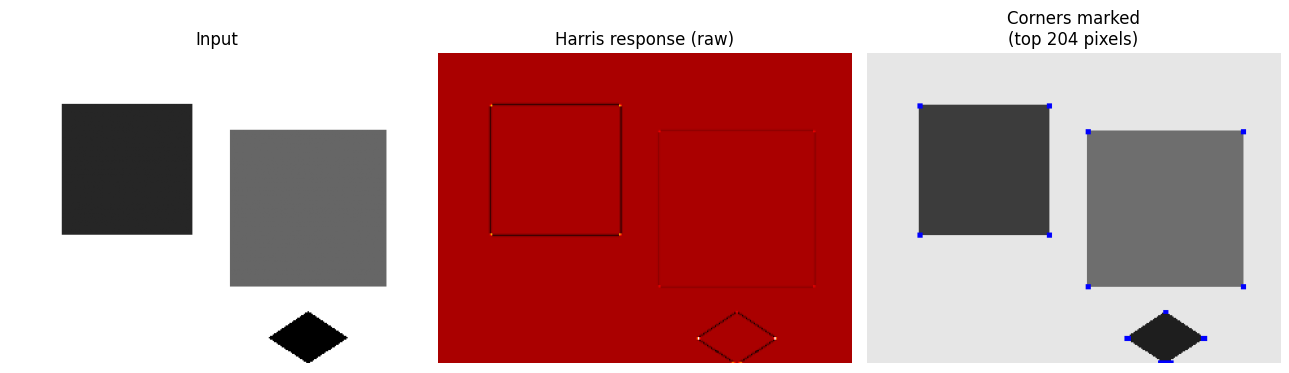

Harris fires brightest at exactly the rectangle corners and the diamond tips.


In [2]:
# Apply Harris corner detection
gray = np.float32(img)

# blockSize = neighborhood window size, ksize = Sobel kernel for gradients, k = Harris parameter
harris_response = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

# Dilate so corner peaks become visible dots
harris_response_dilated = cv2.dilate(harris_response, None)

# Threshold: keep only strong responses (top 1% of max)
threshold = 0.01 * harris_response.max()
img_corners = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
img_corners[harris_response_dilated > threshold] = [255, 0, 0]   # red
img_corners_rgb = cv2.cvtColor(img_corners, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Input")
axes[1].imshow(harris_response, cmap="hot")
axes[1].set_title("Harris response (raw)")
axes[2].imshow(img_corners_rgb)
axes[2].set_title(f"Corners marked\n(top {(harris_response_dilated > threshold).sum()} pixels)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Harris fires brightest at exactly the rectangle corners and the diamond tips.")

## 3. Shi-Tomasi - "Good Features To Track" (1994)

Shi & Tomasi proposed a small but important tweak to Harris:

- **Harris response:** $R = \det(M) - k \cdot \text{trace}(M)^2$ (depends on tuning `k`)
- **Shi-Tomasi response:** $R = \min(\lambda_1, \lambda_2)$ (just the smaller eigenvalue)

The Shi-Tomasi variant is empirically more stable and is what you should use when you specifically want **points to track** in a video. OpenCV exposes it as `cv2.goodFeaturesToTrack`.


Detected 19 corners
First 3 corner coords (x, y):
[[260. 220.]
 [200. 220.]
 [140. 140.]]


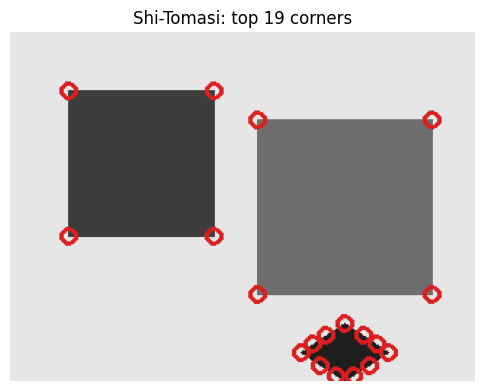

In [3]:
# Use goodFeaturesToTrack (Shi-Tomasi) - returns the N best corners directly
corners = cv2.goodFeaturesToTrack(
    gray,
    maxCorners=50,
    qualityLevel=0.01,
    minDistance=10,
    blockSize=3,
)

print(f"Detected {len(corners)} corners")
print(f"First 3 corner coords (x, y):\n{corners[:3].reshape(-1, 2)}")

img_st = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
for c in corners:
    x, y = c.ravel().astype(int)
    cv2.circle(img_st, (x, y), 5, (220, 30, 30), 2)

plt.figure(figsize=(6, 5))
plt.imshow(img_st)
plt.title(f"Shi-Tomasi: top {len(corners)} corners")
plt.axis("off")
plt.show()

## 4. SIFT - Scale-Invariant Feature Transform (Lowe, 1999)

Harris finds corners but isn't **scale-invariant** - a corner at one zoom level may not look like a corner at another. SIFT solved this and became the most influential pre-deep-learning feature algorithm.

### The 4-stage SIFT pipeline

```
1. Scale-space extrema  -> build a pyramid of blurred images at multiple scales,
                            find points that are extrema in both scale and space
2. Keypoint localization -> refine to sub-pixel accuracy, throw away weak / edge points
3. Orientation assignment -> assign a dominant orientation per keypoint -> rotation invariance
4. Descriptor            -> 128-dim vector built from gradient orientation histograms
                            in 16 sub-regions around the keypoint
```

### What SIFT gives you

- A list of keypoints, each with `(x, y, scale, orientation, response)`
- A `(N, 128)` descriptor matrix - one row per keypoint

### Key facts (2026 status)

- SIFT was patented for years; the patent expired in **March 2020** so it's now free.
- Available as `cv2.SIFT_create()` in modern OpenCV (no `opencv-contrib` needed).
- Still used heavily in robotics / SLAM / 3D reconstruction where reliability beats raw speed.


Detected 98 SIFT keypoints
Descriptor matrix shape: (98, 128)  (N, 128)
Sample keypoint: x=29.7, y=251.3, size=2.5, angle=96.9


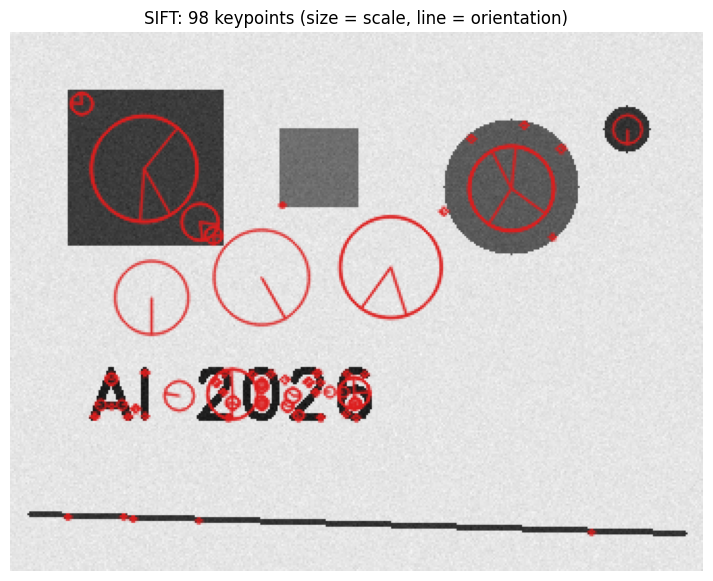

In [4]:
# Build a richer test image so SIFT has enough texture to lock onto
np.random.seed(0)
H, W = 280, 360
scene = np.full((H, W), 230, dtype=np.uint8)

# Several shapes at different scales
cv2.rectangle(scene, (30, 30), (110, 110), 60, -1)
cv2.rectangle(scene, (140, 50), (180, 90), 110, -1)
cv2.circle(scene, (260, 80), 35, 90, -1)
cv2.circle(scene, (320, 50), 12, 50, -1)
cv2.putText(scene, "AI 2026", (40, 200), cv2.FONT_HERSHEY_DUPLEX, 1.2, 30, 2)
cv2.line(scene, (10, 250), (350, 260), 50, 2)

# Add slight texture so SIFT has more keypoints
texture = np.random.normal(0, 5, scene.shape)
scene = np.clip(scene.astype(np.float32) + texture, 0, 255).astype(np.uint8)

# Create a SIFT detector
sift = cv2.SIFT_create(nfeatures=200)
keypoints, descriptors = sift.detectAndCompute(scene, None)

print(f"Detected {len(keypoints)} SIFT keypoints")
print(f"Descriptor matrix shape: {descriptors.shape}  (N, 128)")
print(f"Sample keypoint: x={keypoints[0].pt[0]:.1f}, y={keypoints[0].pt[1]:.1f}, "
      f"size={keypoints[0].size:.1f}, angle={keypoints[0].angle:.1f}")

# Visualize - the rich draw mode shows scale (circle size) and orientation (line)
img_sift = cv2.cvtColor(scene, cv2.COLOR_GRAY2RGB)
img_sift = cv2.drawKeypoints(
    img_sift, keypoints, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    color=(220, 30, 30),
)

plt.figure(figsize=(9, 7))
plt.imshow(img_sift)
plt.title(f"SIFT: {len(keypoints)} keypoints (size = scale, line = orientation)")
plt.axis("off")
plt.show()

### 4.1 - Why "scale-invariant"? Detect the same points after zooming

SIFT's whole purpose is to find the **same** physical points across different zoom levels. Let's prove it.


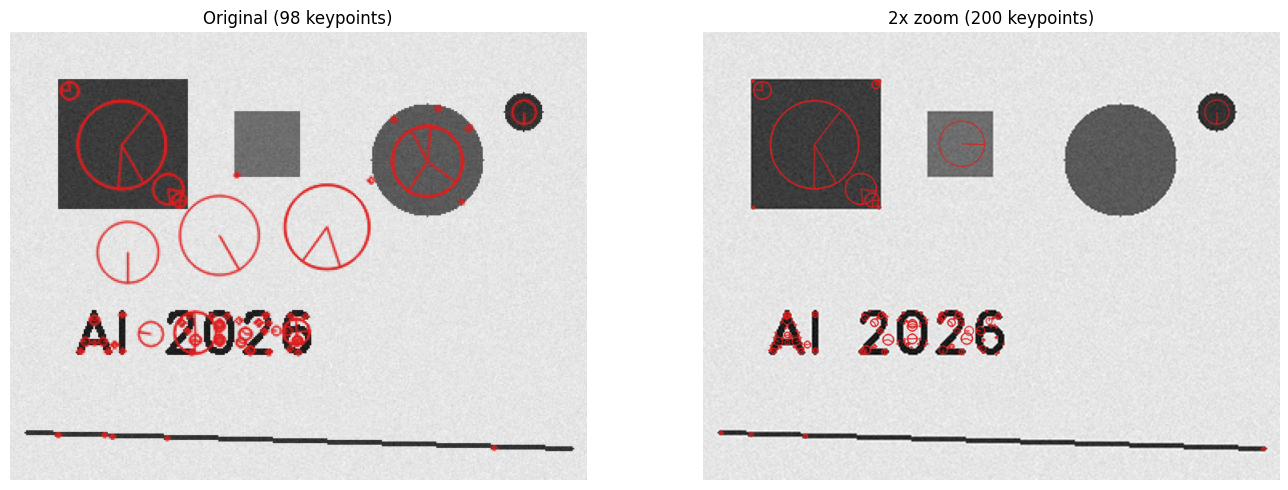

Notice the keypoint circles are LARGER in the zoomed image -
SIFT detected the same physical points but at the appropriate larger scale.


In [5]:
# Make a zoomed version of the same scene
zoomed = cv2.resize(scene, (W * 2, H * 2), interpolation=cv2.INTER_CUBIC)

kp1, des1 = sift.detectAndCompute(scene, None)
kp2, des2 = sift.detectAndCompute(zoomed, None)

vis1 = cv2.drawKeypoints(
    cv2.cvtColor(scene, cv2.COLOR_GRAY2RGB), kp1, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS, color=(220, 30, 30),
)
vis2 = cv2.drawKeypoints(
    cv2.cvtColor(zoomed, cv2.COLOR_GRAY2RGB), kp2, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS, color=(220, 30, 30),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(vis1)
axes[0].set_title(f"Original ({len(kp1)} keypoints)")
axes[1].imshow(vis2)
axes[1].set_title(f"2x zoom ({len(kp2)} keypoints)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Notice the keypoint circles are LARGER in the zoomed image -")
print("SIFT detected the same physical points but at the appropriate larger scale.")

## 5. ORB - Oriented FAST and Rotated BRIEF (2011)

ORB was designed at OpenCV Labs as an **open-source, fast** alternative to SIFT/SURF (which were patented at the time).

### What ORB combines

- **FAST corner detector** (2006) - extremely fast keypoint detection
- **BRIEF descriptor** (2010) - binary descriptor (just 256 bits per keypoint)
- ORB adds: orientation to FAST + rotation handling for BRIEF

### SIFT vs ORB - when to use which

| Aspect | SIFT | ORB |
|---|---|---|
| Speed | Slow | **Very fast (~10x SIFT)** |
| Descriptor | 128 floats (512 bytes) | **256 bits (32 bytes)** |
| Matching distance | Euclidean (L2) | **Hamming (XOR)** |
| Accuracy | **Higher**, more discriminative | Slightly lower |
| Patent | Free since 2020 | **Always free** |
| Best for | Offline, accuracy matters | Real-time, mobile, SLAM |

In production, you'll often see ORB in robotics and AR (e.g., ORB-SLAM3) and SIFT in 3D reconstruction tools like COLMAP.


Detected 187 ORB keypoints
Descriptor matrix shape: (187, 32)  dtype=uint8
(ORB descriptors are uint8 -> 32 bytes = 256 bits per keypoint)


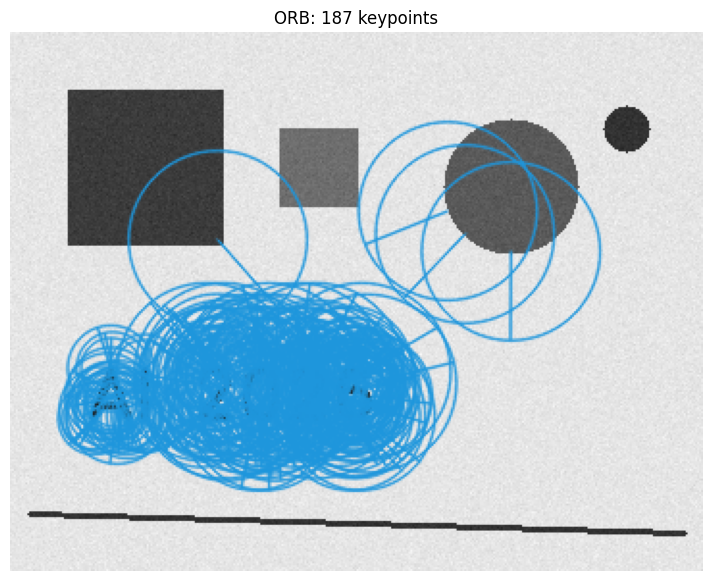

In [6]:
# Detect ORB features on the same scene
orb = cv2.ORB_create(nfeatures=200)
kp_orb, des_orb = orb.detectAndCompute(scene, None)

print(f"Detected {len(kp_orb)} ORB keypoints")
print(f"Descriptor matrix shape: {des_orb.shape}  dtype={des_orb.dtype}")
print(f"(ORB descriptors are uint8 -> 32 bytes = 256 bits per keypoint)")

img_orb = cv2.cvtColor(scene, cv2.COLOR_GRAY2RGB)
img_orb = cv2.drawKeypoints(
    img_orb, kp_orb, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    color=(30, 150, 220),
)

plt.figure(figsize=(9, 7))
plt.imshow(img_orb)
plt.title(f"ORB: {len(kp_orb)} keypoints")
plt.axis("off")
plt.show()

In [7]:
# Speed comparison: how much faster is ORB on the same image?
import time

# Warm up
sift.detectAndCompute(scene, None)
orb.detectAndCompute(scene, None)

# Time SIFT
t0 = time.perf_counter()
for _ in range(20):
    sift.detectAndCompute(scene, None)
sift_time = (time.perf_counter() - t0) / 20 * 1000   # ms per call

# Time ORB
t0 = time.perf_counter()
for _ in range(20):
    orb.detectAndCompute(scene, None)
orb_time = (time.perf_counter() - t0) / 20 * 1000

print(f"SIFT: {sift_time:6.2f} ms per image")
print(f"ORB:  {orb_time:6.2f} ms per image")
print(f"ORB is roughly {sift_time / orb_time:.1f}x faster on this scene.")

SIFT:  12.24 ms per image
ORB:    1.39 ms per image
ORB is roughly 8.8x faster on this scene.


## 6. Feature Matching - Linking Keypoints Across Images

Detection alone is useless. The real magic happens when you **match** keypoints between two images.

### The matching problem

Given descriptors `D1` from image 1 and `D2` from image 2, for each row in `D1` find the most similar row in `D2`.

### Distance metrics

| Descriptor type | Distance |
|---|---|
| SIFT (float vectors) | L2 / Euclidean |
| ORB / BRIEF (binary) | Hamming (count differing bits) |

### Matching algorithms

| Method | How | When |
|---|---|---|
| **Brute Force** | Compare every pair | Small descriptor sets, simplest, most accurate |
| **FLANN** | Approximate nearest-neighbor index (KD-tree, LSH) | Thousands of features, fast lookup |

### Lowe's ratio test

A single best match is unreliable. Lowe's trick: get the **two** nearest neighbors `m1, m2` and only accept the match if:

```
distance(m1) < 0.75 * distance(m2)
```

If the second-best match is almost as close as the best, the keypoint is ambiguous - throw it away.


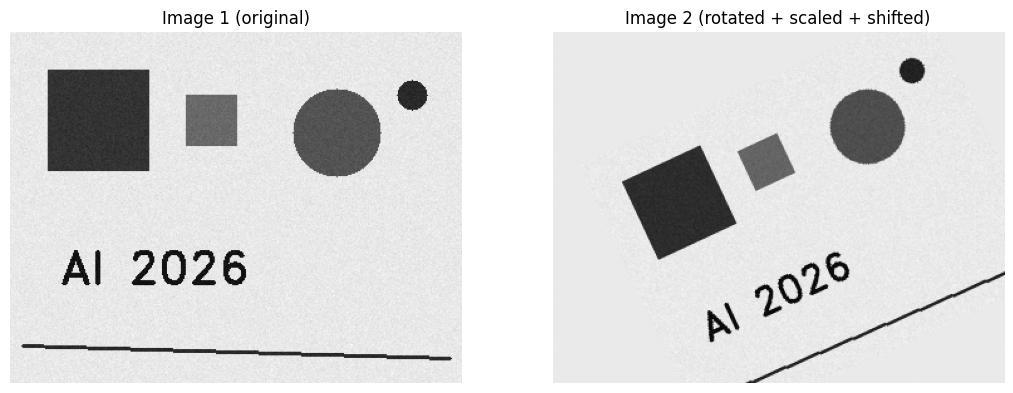

In [8]:
# Create a transformed version of our scene to match against
H_orig, W_orig = scene.shape
M = cv2.getRotationMatrix2D((W_orig/2, H_orig/2), 25, 0.85)   # rotate 25 deg, shrink to 85%
M[0, 2] += 30   # also shift right
M[1, 2] += 10
scene_warped = cv2.warpAffine(scene, M, (W_orig, H_orig), borderValue=230)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(scene, cmap="gray")
axes[0].set_title("Image 1 (original)")
axes[1].imshow(scene_warped, cmap="gray")
axes[1].set_title("Image 2 (rotated + scaled + shifted)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

Image 1: 98 keypoints
Image 2: 105 keypoints

Raw knn pairs: 98
After Lowe's ratio test: 51 good matches


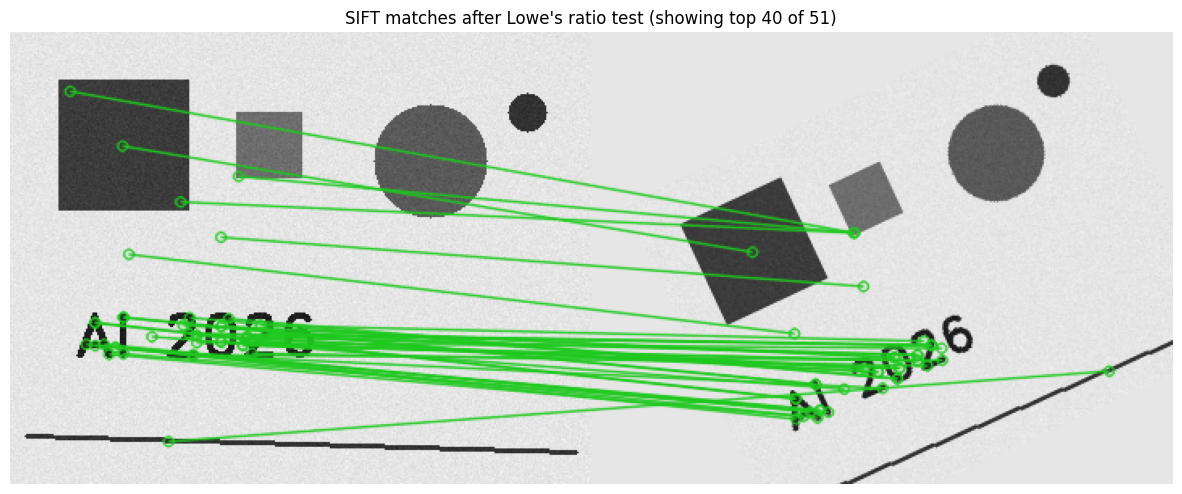

In [9]:
# Detect SIFT features in both images
sift = cv2.SIFT_create(nfeatures=400)
kp1, des1 = sift.detectAndCompute(scene, None)
kp2, des2 = sift.detectAndCompute(scene_warped, None)

print(f"Image 1: {len(kp1)} keypoints")
print(f"Image 2: {len(kp2)} keypoints")

# Brute-force matcher with L2 norm (correct for SIFT)
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

# Get the 2 nearest neighbors for each query descriptor (knnMatch with k=2)
knn_matches = bf.knnMatch(des1, des2, k=2)

# Lowe's ratio test
good_matches = []
for m, n in knn_matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print(f"\nRaw knn pairs: {len(knn_matches)}")
print(f"After Lowe's ratio test: {len(good_matches)} good matches")

# Visualize the good matches
match_img = cv2.drawMatches(
    cv2.cvtColor(scene, cv2.COLOR_GRAY2RGB), kp1,
    cv2.cvtColor(scene_warped, cv2.COLOR_GRAY2RGB), kp2,
    good_matches[:40],   # show top 40 for readability
    None,
    matchColor=(30, 200, 30),
    singlePointColor=(220, 30, 30),
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)

plt.figure(figsize=(15, 6))
plt.imshow(match_img)
plt.title(f"SIFT matches after Lowe's ratio test (showing top 40 of {len(good_matches)})")
plt.axis("off")
plt.show()

### 6.1 - The same matching with ORB + Hamming distance

For binary descriptors like ORB, you must use Hamming distance, not L2.


ORB: 200 good matches after ratio test


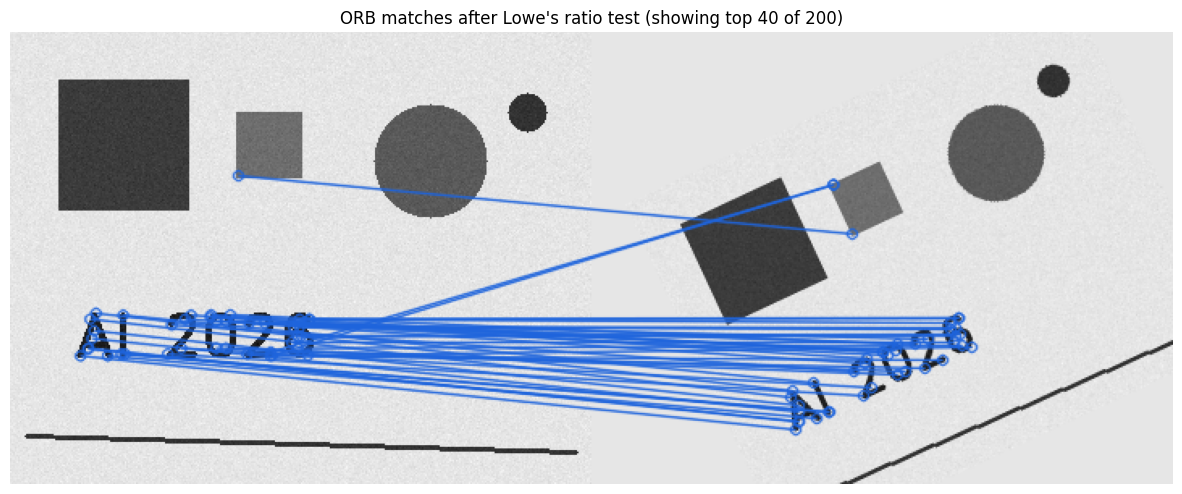

In [10]:
# ORB detection + matching with Hamming distance
orb = cv2.ORB_create(nfeatures=500)
kp1_o, des1_o = orb.detectAndCompute(scene, None)
kp2_o, des2_o = orb.detectAndCompute(scene_warped, None)

bf_orb = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
knn_orb = bf_orb.knnMatch(des1_o, des2_o, k=2)

good_orb = []
for pair in knn_orb:
    if len(pair) < 2:
        continue
    m, n = pair
    if m.distance < 0.75 * n.distance:
        good_orb.append(m)

print(f"ORB: {len(good_orb)} good matches after ratio test")

match_img_orb = cv2.drawMatches(
    cv2.cvtColor(scene, cv2.COLOR_GRAY2RGB), kp1_o,
    cv2.cvtColor(scene_warped, cv2.COLOR_GRAY2RGB), kp2_o,
    good_orb[:40], None,
    matchColor=(30, 100, 220),
    singlePointColor=(220, 30, 30),
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)

plt.figure(figsize=(15, 6))
plt.imshow(match_img_orb)
plt.title(f"ORB matches after Lowe's ratio test (showing top 40 of {len(good_orb)})")
plt.axis("off")
plt.show()

## 7. Geometric Verification with RANSAC

Even after Lowe's ratio test, some matches will be wrong (outliers). The next step is to fit a **geometric model** that explains a consistent set of matches and discards the rest.

### The model: homography

A **homography** is a 3x3 matrix that maps points from one plane to another under any perspective transform. If your two images are of the same scene from different viewpoints, the matched points should all be related by a single homography.

### RANSAC (RANdom SAmple Consensus)

```
Repeat for N iterations:
  1. Randomly sample 4 matches
  2. Compute a homography from those 4
  3. Count how many other matches "agree" with this homography (inliers)
Keep the homography with the most inliers.
```

This automatically separates **inliers** (real matches) from **outliers** (bogus matches).

OpenCV exposes this via `cv2.findHomography(..., method=cv2.RANSAC)` which returns the homography **and** an inlier mask.


Total good matches:    51
RANSAC inliers:        34
Outliers rejected:     17

Estimated homography:
[[  0.796   0.393  17.129]
 [ -0.37    0.822 105.082]
 [  0.      0.      1.   ]]


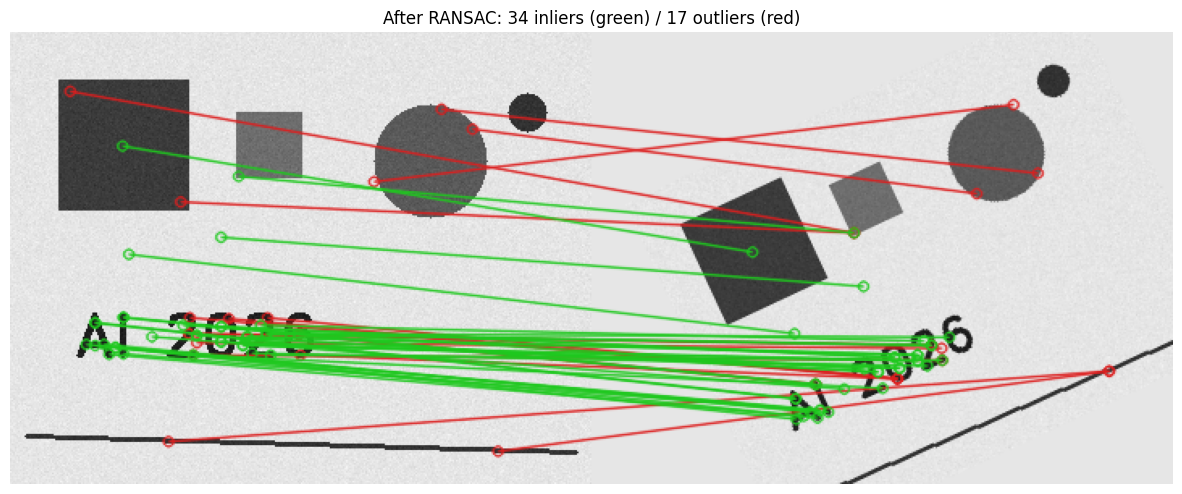

In [11]:
# Use the SIFT good_matches from earlier and run RANSAC
src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

H_matrix, inlier_mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransacReprojThreshold=4.0)
inlier_mask = inlier_mask.ravel().astype(bool)

print(f"Total good matches:    {len(good_matches)}")
print(f"RANSAC inliers:        {inlier_mask.sum()}")
print(f"Outliers rejected:     {(~inlier_mask).sum()}")
print(f"\nEstimated homography:\n{H_matrix.round(3)}")

# Visualize: inliers in green, outliers in red
inlier_matches = [m for m, ok in zip(good_matches, inlier_mask) if ok]
outlier_matches = [m for m, ok in zip(good_matches, inlier_mask) if not ok]

vis = cv2.drawMatches(
    cv2.cvtColor(scene, cv2.COLOR_GRAY2RGB), kp1,
    cv2.cvtColor(scene_warped, cv2.COLOR_GRAY2RGB), kp2,
    outlier_matches, None,
    matchColor=(220, 30, 30),
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)
vis = cv2.drawMatches(
    cv2.cvtColor(scene, cv2.COLOR_GRAY2RGB), kp1,
    cv2.cvtColor(scene_warped, cv2.COLOR_GRAY2RGB), kp2,
    inlier_matches[:50], vis,
    matchColor=(30, 200, 30),
    flags=cv2.DrawMatchesFlags_DRAW_OVER_OUTIMG | cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)

plt.figure(figsize=(15, 6))
plt.imshow(vis)
plt.title(f"After RANSAC: {inlier_mask.sum()} inliers (green) / {(~inlier_mask).sum()} outliers (red)")
plt.axis("off")
plt.show()

## 8. Capstone - Panorama Stitching

Putting it all together. Given two overlapping images, stitch them into a panorama.

### The pipeline

```
Image A   Image B
  |         |
  v         v
SIFT detect & describe (both)
  |
  v
Brute-force knn match + Lowe's ratio test
  |
  v
RANSAC -> homography H mapping B onto A's frame
  |
  v
warpPerspective B with H, paste onto canvas next to A
  |
  v
Panorama
```


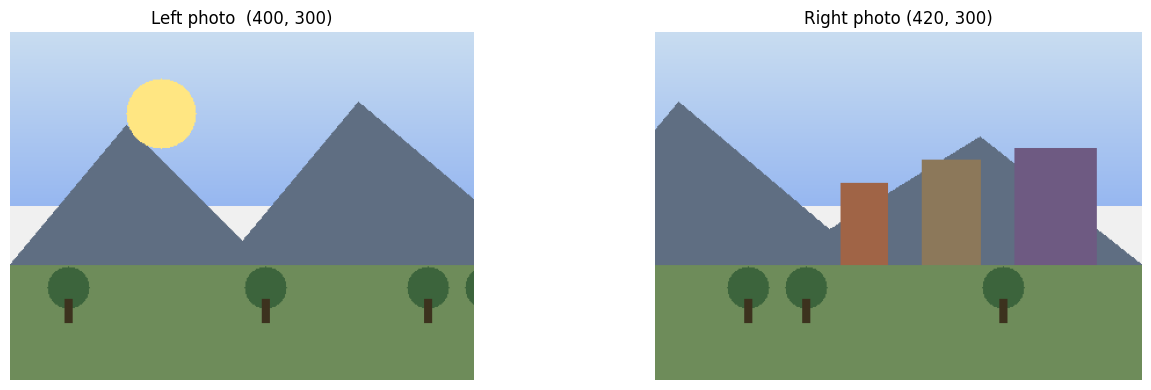

In [12]:
# Synthesize two overlapping "photos" of a wide scene
# Build a wide panoramic source, then take two cropped + warped views of it

panorama_src = np.full((300, 700, 3), 240, dtype=np.uint8)

# Sky gradient
for y in range(150):
    panorama_src[y, :] = (200 - y // 3, 220 - y // 4, 240)
# Ground
panorama_src[200:, :] = (110, 140, 90)
# Mountains
mountains = np.array([[0, 200], [100, 80], [200, 180], [300, 60], [430, 170],
                     [560, 90], [700, 200]], dtype=np.int32)
cv2.fillPoly(panorama_src, [mountains], (95, 110, 130))

# A few buildings on the right
cv2.rectangle(panorama_src, (440, 130), (480, 200), (160, 100, 70), -1)
cv2.rectangle(panorama_src, (510, 110), (560, 200), (140, 120, 90), -1)
cv2.rectangle(panorama_src, (590, 100), (660, 200), (110, 90, 130), -1)

# A sun on the left
cv2.circle(panorama_src, (130, 70), 30, (255, 230, 130), -1)

# Trees on the bottom
for cx in [50, 220, 360, 410, 580]:
    cv2.circle(panorama_src, (cx, 220), 18, (60, 100, 60), -1)
    cv2.rectangle(panorama_src, (cx-3, 230), (cx+3, 250), (60, 50, 30), -1)

# Take two overlapping views
img_left = panorama_src[:, 0:400].copy()
img_right = panorama_src[:, 280:].copy()    # overlaps cols 280-400 (~120 px overlap)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(img_left)
axes[0].set_title(f"Left photo  {img_left.shape[:2][::-1]}")
axes[1].imshow(img_right)
axes[1].set_title(f"Right photo {img_right.shape[:2][::-1]}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [13]:
# Step 1-3: Detect, describe, match
gray_left = cv2.cvtColor(img_left, cv2.COLOR_RGB2GRAY)
gray_right = cv2.cvtColor(img_right, cv2.COLOR_RGB2GRAY)

sift = cv2.SIFT_create(nfeatures=2000)
kp_l, des_l = sift.detectAndCompute(gray_left, None)
kp_r, des_r = sift.detectAndCompute(gray_right, None)

bf = cv2.BFMatcher(cv2.NORM_L2)
knn = bf.knnMatch(des_r, des_l, k=2)   # match RIGHT into LEFT (we'll warp right onto left)

good = []
for m, n in knn:
    if m.distance < 0.75 * n.distance:
        good.append(m)

print(f"Left  keypoints: {len(kp_l)}")
print(f"Right keypoints: {len(kp_r)}")
print(f"Good matches:    {len(good)}")

# Step 4: RANSAC homography (right -> left coordinate frame)
src_pts = np.float32([kp_r[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
dst_pts = np.float32([kp_l[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
H_RL, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 4.0)

print(f"RANSAC inliers:  {int(mask.sum())} / {len(good)}")
print(f"\nHomography (right -> left frame):\n{H_RL.round(3)}")

Left  keypoints: 49
Right keypoints: 51
Good matches:    8
RANSAC inliers:  5 / 8

Homography (right -> left frame):
[[-4.21000e-01 -6.32000e-01  1.78857e+02]
 [-3.64000e-01 -5.52000e-01  1.55225e+02]
 [-2.00000e-03 -4.00000e-03  1.00000e+00]]


Final panorama size: (300, 820, 3)


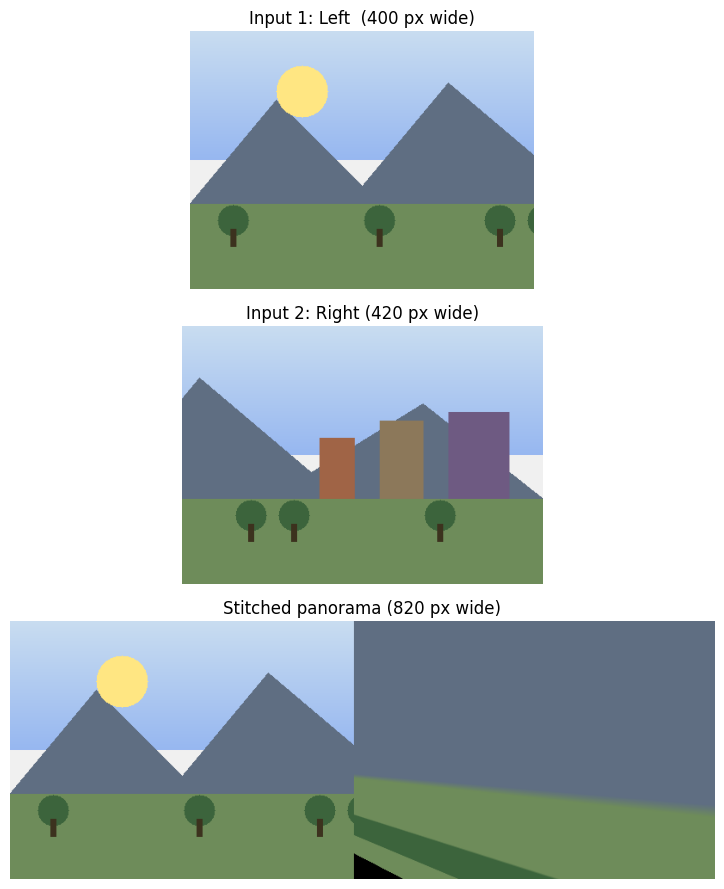


This is exactly how the panorama mode in your phone works -
just with extra blending steps to hide the seam.


In [14]:
# Step 5: Warp the RIGHT image onto a wide canvas, then paste LEFT on top
canvas_h = max(img_left.shape[0], img_right.shape[0])
canvas_w = img_left.shape[1] + img_right.shape[1]

# Warp right image into the canvas using the homography
warped_right = cv2.warpPerspective(img_right, H_RL, (canvas_w, canvas_h))

# Paste left image on top (at its original position, top-left of canvas)
panorama = warped_right.copy()
panorama[0:img_left.shape[0], 0:img_left.shape[1]] = img_left

# Trim trailing black columns (where nothing was painted)
gray_pan = cv2.cvtColor(panorama, cv2.COLOR_RGB2GRAY)
nonzero_cols = np.where(gray_pan.sum(axis=0) > 0)[0]
if len(nonzero_cols) > 0:
    panorama = panorama[:, : nonzero_cols.max() + 1]

print(f"Final panorama size: {panorama.shape}")

fig, axes = plt.subplots(3, 1, figsize=(14, 9))
axes[0].imshow(img_left)
axes[0].set_title(f"Input 1: Left  ({img_left.shape[1]} px wide)")
axes[1].imshow(img_right)
axes[1].set_title(f"Input 2: Right ({img_right.shape[1]} px wide)")
axes[2].imshow(panorama)
axes[2].set_title(f"Stitched panorama ({panorama.shape[1]} px wide)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("\nThis is exactly how the panorama mode in your phone works -")
print("just with extra blending steps to hide the seam.")

## 9. Recap

- **Features = repeatable, distinctive image points** that survive scale, rotation, and lighting changes
- **Corners are the canonical feature** - flat regions and edges are bad
- **Harris (1988)** - the geometric foundation, uses the structure tensor and eigenvalues
- **Shi-Tomasi (1994)** - small but useful improvement; OpenCV's `goodFeaturesToTrack`
- **SIFT (1999)** - scale + rotation invariant, 128-dim float descriptors, accuracy king
- **ORB (2011)** - fast, free, binary descriptors, the real-time choice for SLAM/AR
- **Brute Force + knnMatch + Lowe's ratio test** - the standard matching pipeline
- **RANSAC + homography** - geometric verification removes outlier matches
- **Capstone** - stitched two photos into a panorama using the full pipeline

### One-line takeaway

> **Features turn images into a few hundred locked-on points - the bridge that lets you align, match, and reconstruct scenes long before deep learning enters the picture.**

---

### Coming next: Notebook 05 - Classical ML for Vision

We'll go deep on:

- HOG (Histogram of Oriented Gradients) - features for whole regions
- SVM classifiers on image features
- Bag-of-Visual-Words (BoVW) for image categorization
- Train a classical pedestrian detector
- Why this matters even in 2026 (small data, edge devices, interpretability)

---

<div style="background:linear-gradient(135deg,#0f172a 0%,#1e3a8a 100%);padding:18px;border-radius:10px;color:white;text-align:center;font-family:'Segoe UI',sans-serif;margin-top:18px;">
<b>End of Notebook 04 - Computer Vision Series - 2025-2026</b><br>
<span style="opacity:0.8;font-size:13px;">Features locked in. Next stop: turning features into decisions with classical ML.</span>
</div>